In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/processed/clean_data.csv", parse_dates=["InvoiceDate"])
features = pd.read_csv("../data/processed/features.csv")

print(df.shape)
features.head()

(397884, 9)


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,TotalItems,Tenure,return_rate,last_purchase_month,season,country_Belgium,country_France,country_Germany,country_Other,country_Spain,country_United Kingdom,churned
0,12346,254,1,77183.60,77183.600000,1,74215,0,0.500000,1,0,False,False,False,False,False,True,1
1,12347,58,5,2790.86,22.506935,82,1590,237,0.000000,8,2,False,False,False,True,False,False,0
2,12348,4,4,1797.24,57.975484,22,2341,282,0.000000,9,3,False,False,False,True,False,False,1
3,12350,239,1,334.40,19.670588,17,197,0,0.000000,2,0,False,False,False,True,False,False,1
4,12352,1,7,2194.31,31.347286,47,409,224,0.109635,9,3,False,False,False,True,False,False,0


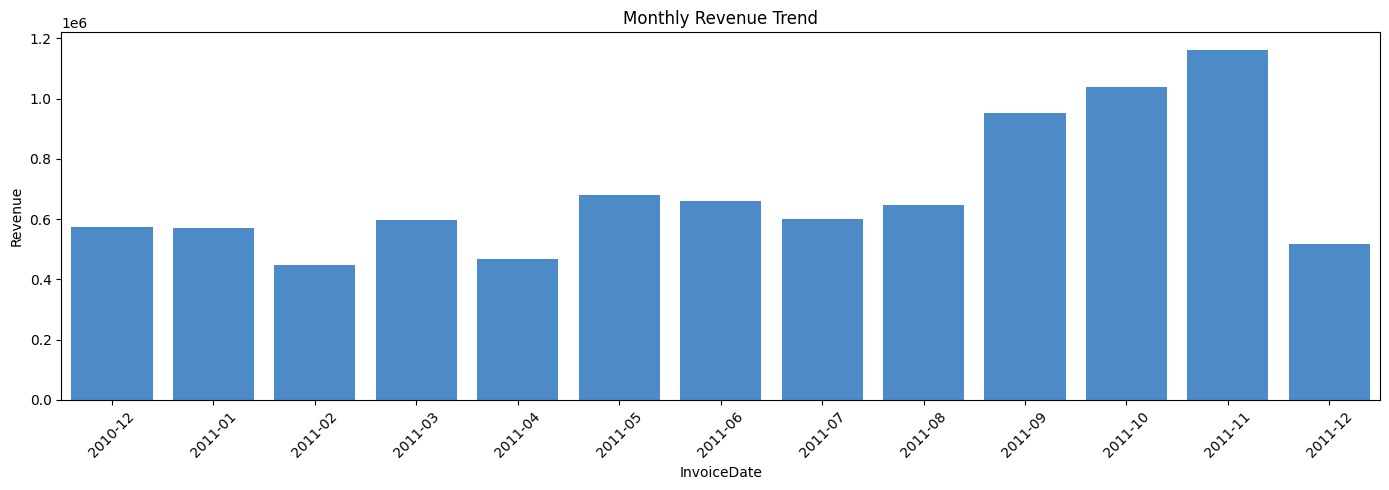

Saved: reports/monthly_revenue.png


In [2]:
monthly = df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"].sum().reset_index()
monthly["InvoiceDate"] = monthly["InvoiceDate"].astype(str)

plt.figure(figsize=(14, 5))
sns.barplot(data=monthly, x="InvoiceDate", y="Revenue", color="#378ADD")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/monthly_revenue.png", dpi=150)
plt.show()
print("Saved: reports/monthly_revenue.png")

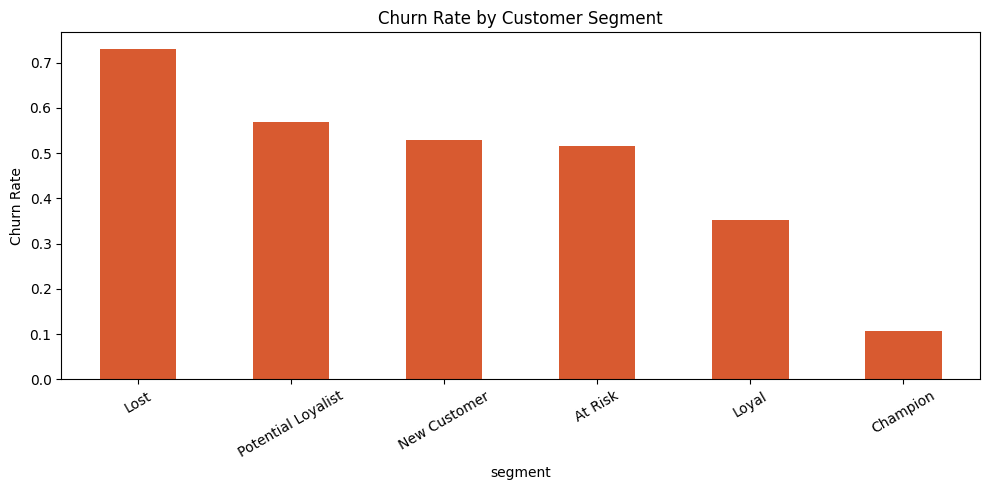

In [3]:
# RFM segment labeling
def label_segment(row):
    r = row["Recency"]
    f = row["Frequency"]
    if r <= 30 and f >= 5:
        return "Champion"
    elif r <= 60 and f >= 3:
        return "Loyal"
    elif r <= 30 and f < 3:
        return "New Customer"
    elif r > 120 and f >= 3:
        return "At Risk"
    elif r > 180:
        return "Lost"
    else:
        return "Potential Loyalist"

features["segment"] = features.apply(label_segment, axis=1)

seg_churn = features.groupby("segment")["churned"].mean().sort_values(ascending=False)
seg_churn.plot(kind="bar", color="#D85A30", figsize=(10, 5))
plt.title("Churn Rate by Customer Segment")
plt.ylabel("Churn Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../reports/churn_by_segment.png", dpi=150)
plt.show()

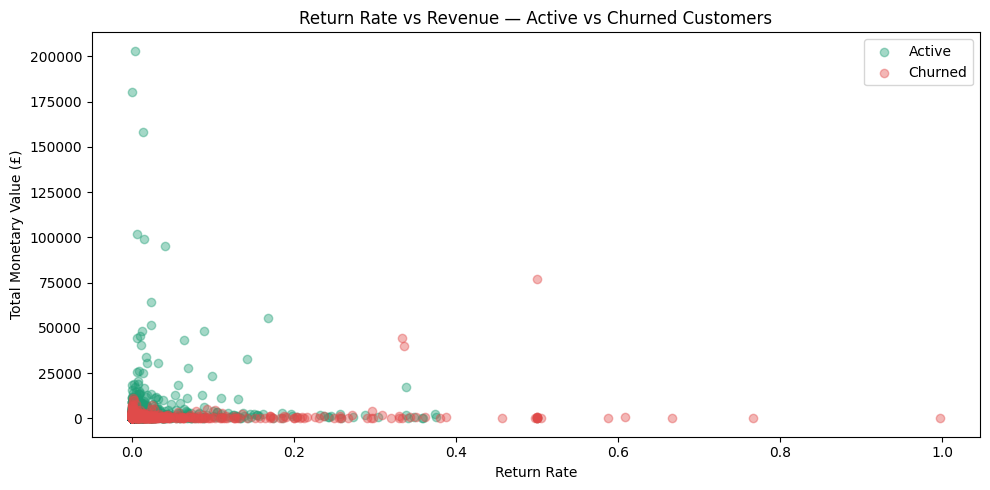

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    features[features["churned"]==0]["return_rate"],
    features[features["churned"]==0]["Monetary"],
    alpha=0.4, label="Active", color="#1D9E75"
)
ax.scatter(
    features[features["churned"]==1]["return_rate"],
    features[features["churned"]==1]["Monetary"],
    alpha=0.4, label="Churned", color="#E24B4A"
)
ax.set_xlabel("Return Rate")
ax.set_ylabel("Total Monetary Value (£)")
ax.set_title("Return Rate vs Revenue — Active vs Churned Customers")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/return_rate_vs_churn.png", dpi=150)
plt.show()

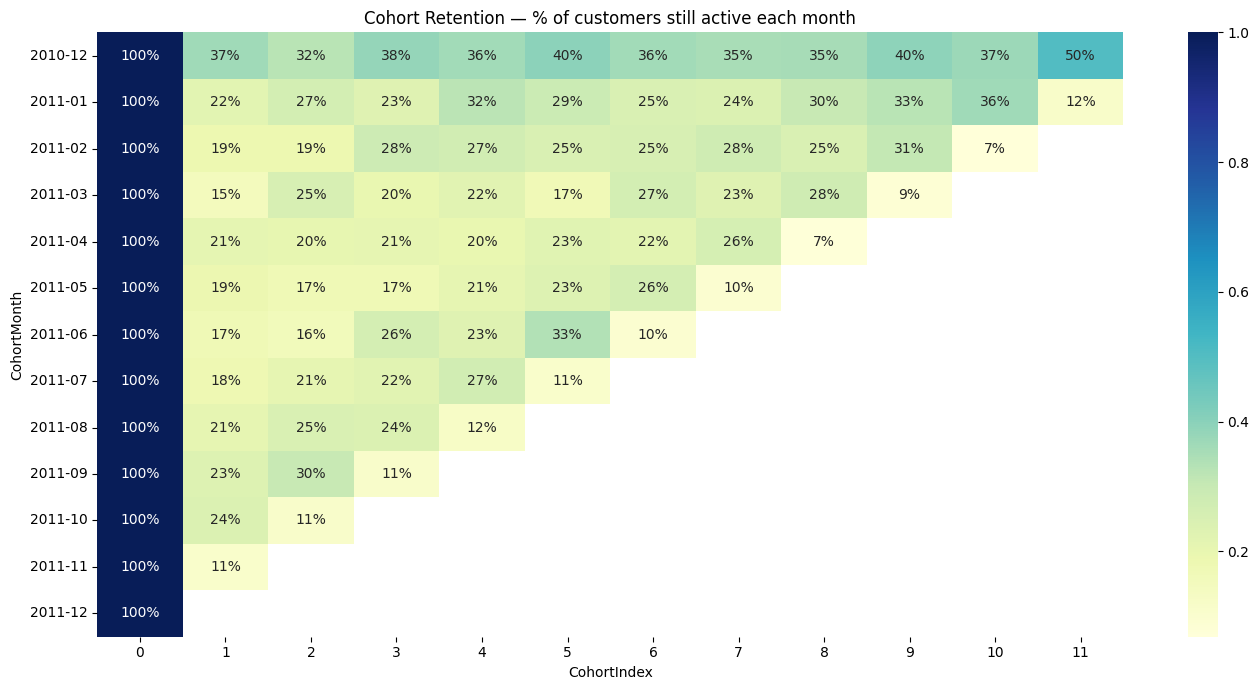

In [5]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
df["CohortMonth"] = df.groupby("CustomerID")["InvoiceDate"].transform("min").dt.to_period("M")
df["CohortIndex"] = (df["InvoiceMonth"] - df["CohortMonth"]).apply(lambda x: x.n)

cohort_data = df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")
cohort_pct = cohort_pivot.divide(cohort_pivot[0], axis=0)

plt.figure(figsize=(14, 7))
sns.heatmap(cohort_pct.iloc[:, :12], annot=True, fmt=".0%", cmap="YlGnBu")
plt.title("Cohort Retention — % of customers still active each month")
plt.tight_layout()
plt.savefig("../reports/cohort_retention.png", dpi=150)
plt.show()